In [3]:
import pandas as pd
import numpy as np

# column names according to UCI dataset
columns = [
    "age","sex","cp","trestbps","chol","fbs","restecg",
    "thalach","exang","oldpeak","slope","ca","thal","target"
]

# load dataset
# Please upload 'processed_cleveland.csv' to your Colab environment (e.g., by dragging and dropping it into the files pane).
df = pd.read_csv(r"C:\Users\Administrator\Downloads\processed_cleveland.csv", names=columns)

print("Shape of dataset:", df.shape)

print("\nFirst 5 rows:")
print(df.head())

print("\nMissing values count:")
print(df.isin(['?']).sum())

Shape of dataset: (304, 14)

First 5 rows:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0   0.0  1.0  2.0       3.0    4.0  5.0      6.0      7.0    8.0      9.0   
1  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
2  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
3  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
4  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   

   slope   ca thal  target  
0   10.0   11   12      13  
1    3.0  0.0  6.0       0  
2    2.0  3.0  3.0       2  
3    2.0  2.0  7.0       1  
4    3.0  0.0  3.0       0  

Missing values count:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [4]:
# Step 2: Replace '?' with NaN
df.replace("?", np.nan, inplace=True)

# Convert columns to numeric (important for ML models)
df = df.apply(pd.to_numeric)

# Step 3: Remove rows with missing values
df = df.dropna()

# Check new shape
print("Shape after removing missing values:", df.shape)

# Confirm no missing values remain
print("\nRemaining missing values:")
print(df.isnull().sum())

Shape after removing missing values: (298, 14)

Remaining missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [5]:
# Check original target values
print("Original target values:")
print(df["target"].value_counts())

# Convert multiclass target to binary
df["target"] = df["target"].apply(lambda x: 0 if x == 0 else 1)

# Check new target values
print("\nBinary target values:")
print(df["target"].value_counts())

Original target values:
target
0     160
1      54
3      35
2      35
4      13
13      1
Name: count, dtype: int64

Binary target values:
target
0    160
1    138
Name: count, dtype: int64


In [6]:
# Separate features and target

X = df.drop("target", axis=1)
y = df["target"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFirst 5 feature rows:")
print(X.head())

Feature shape: (298, 13)
Target shape: (298,)

First 5 feature rows:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0   0.0  1.0  2.0       3.0    4.0  5.0      6.0      7.0    8.0      9.0   
1  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
2  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
3  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
4  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   

   slope    ca  thal  
0   10.0  11.0  12.0  
1    3.0   0.0   6.0  
2    2.0   3.0   3.0  
3    2.0   2.0   7.0  
4    3.0   0.0   3.0  


In [7]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training samples: (238, 13)
Testing samples: (60, 13)

Training target distribution:
target
0    128
1    110
Name: count, dtype: int64

Testing target distribution:
target
0    32
1    28
Name: count, dtype: int64


In [8]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

print("\nExample scaled row:")
print(X_train_scaled[0])

Scaled training shape: (238, 13)
Scaled testing shape: (60, 13)

Example scaled row:
[ 1.16266209  0.65858556  0.87548869 -1.20785254 -0.0087018  -0.43588989
  1.00422835  0.38645446 -0.698212   -0.37402875 -0.95365381  1.44680395
  0.60157943]


In [9]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# SVM classifier with optimal parameters
svm_model = SVC(
    kernel='rbf',
    C=100,
    gamma=0.001
)

# Train model
svm_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_svm = svm_model.predict(X_test_scaled)

# Accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.8666666666666667

Confusion Matrix:
[[29  3]
 [ 5 23]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.91      0.88        32
           1       0.88      0.82      0.85        28

    accuracy                           0.87        60
   macro avg       0.87      0.86      0.87        60
weighted avg       0.87      0.87      0.87        60



In [10]:
from sklearn.neighbors import KNeighborsClassifier

# Create KNN model with optimal parameters
knn_model = KNeighborsClassifier(
    n_neighbors=100,
    weights='distance',
    metric='euclidean',
    algorithm='auto'
)

# Train model
knn_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_knn = knn_model.predict(X_test_scaled)

# Accuracy
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))


KNN Accuracy: 0.8833333333333333

Confusion Matrix:
[[31  1]
 [ 6 22]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.97      0.90        32
           1       0.96      0.79      0.86        28

    accuracy                           0.88        60
   macro avg       0.90      0.88      0.88        60
weighted avg       0.89      0.88      0.88        60



In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Decision Tree (paper-faithful version)
dt_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=4,
    min_samples_split=2,
    min_samples_leaf=3,
    random_state=42
)

# Train
dt_model.fit(X_train_scaled, y_train)

# Predict
y_pred_dt = dt_model.predict(X_test_scaled)

# Evaluate
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8666666666666667

Confusion Matrix:
[[31  1]
 [ 7 21]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89        32
           1       0.95      0.75      0.84        28

    accuracy                           0.87        60
   macro avg       0.89      0.86      0.86        60
weighted avg       0.88      0.87      0.86        60



In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=40,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8833333333333333

Confusion Matrix:
[[30  2]
 [ 5 23]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.94      0.90        32
           1       0.92      0.82      0.87        28

    accuracy                           0.88        60
   macro avg       0.89      0.88      0.88        60
weighted avg       0.89      0.88      0.88        60



In [13]:
print(f"SVM Accuracy: {svm_accuracy:.4f}")
print(f"KNN Accuracy: {knn_accuracy:.4f}")
print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

SVM Accuracy: 0.8667
KNN Accuracy: 0.8833
Decision Tree Accuracy: 0.8667
Random Forest Accuracy: 0.8833


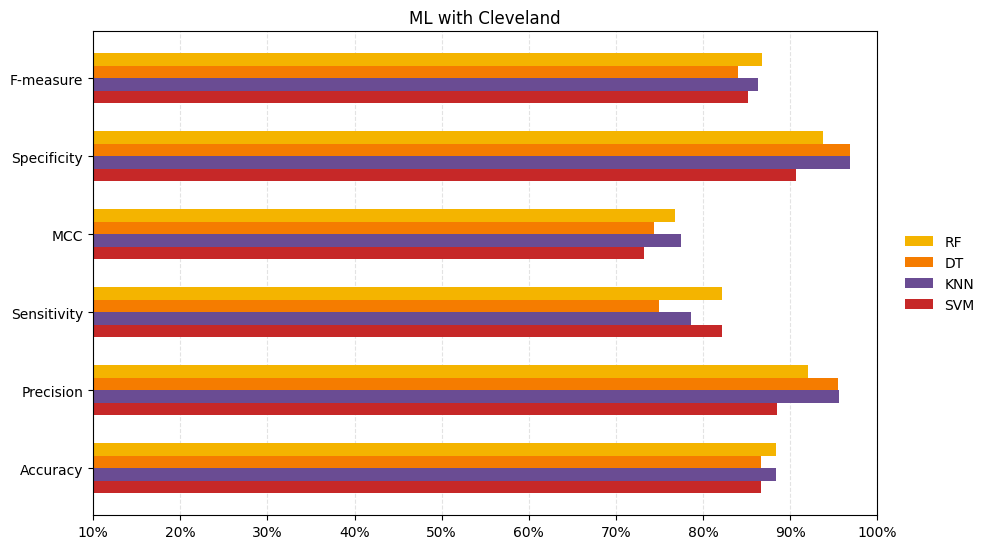

     Accuracy  Precision  Sensitivity     MCC  Specificity  F-measure
RF     0.8833     0.9200       0.8214  0.7680       0.9375     0.8679
DT     0.8667     0.9545       0.7500  0.7441       0.9688     0.8400
KNN    0.8833     0.9565       0.7857  0.7742       0.9688     0.8627
SVM    0.8667     0.8846       0.8214  0.7326       0.9062     0.8519


In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix, accuracy_score


def compute_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Specificity": specificity,
        "F-measure": f1_score(y_true, y_pred, zero_division=0),
    }


model_metrics = {
    "RF": compute_metrics(y_test, y_pred_rf),
    "DT": compute_metrics(y_test, y_pred_dt),
    "KNN": compute_metrics(y_test, y_pred_knn),
    "SVM": compute_metrics(y_test, y_pred_svm),
}

metric_names = ["Accuracy", "Precision", "Sensitivity", "MCC", "Specificity", "F-measure"]
models = ["RF", "DT", "KNN", "SVM"]
colors = {"RF": "#F4B400", "DT": "#F57C00", "KNN": "#6A4C93", "SVM": "#C62828"}

# Reverse so top-to-bottom order matches the sample chart.
metric_names_plot = metric_names[::-1]

fig, ax = plt.subplots(figsize=(10, 5.6))
bar_h = 0.16
y_base = list(range(len(metric_names_plot)))
offsets = [-1.5 * bar_h, -0.5 * bar_h, 0.5 * bar_h, 1.5 * bar_h]

for offset, model in zip(offsets, models):
    values = [model_metrics[model][m] for m in metric_names_plot]
    y_pos = [y + offset for y in y_base]
    ax.barh(y_pos, values, height=bar_h, color=colors[model], label=model)

ax.set_yticks(y_base)
ax.set_yticklabels(metric_names_plot)
ax.invert_yaxis()
ax.set_xlim(0.10, 1.00)
xticks = [i / 10 for i in range(1, 11)]
ax.set_xticks(xticks)
ax.set_xticklabels([f"{int(x * 100)}%" for x in xticks])
ax.grid(axis="x", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)
ax.set_title("ML with Cleveland")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

plt.tight_layout()
plt.show()

# Optional: print values used in the plot.
metrics_df = pd.DataFrame(model_metrics).T[metric_names]
print(metrics_df.round(4))

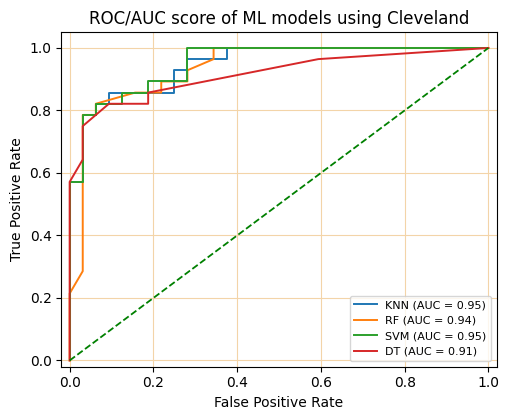

In [15]:
from sklearn.metrics import roc_curve, auc


def get_model_score(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    return model.predict(X)


roc_models = [
    ("KNN", knn_model, "#1f77b4"),
    ("RF", rf_model, "#ff7f0e"),
    ("SVM", svm_model, "#2ca02c"),
    ("DT", dt_model, "#d62728"),
]

plt.figure(figsize=(5.2, 4.3))

for name, model, color in roc_models:
    scores = get_model_score(model, X_test_scaled)
    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linewidth=1.4, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "g--", linewidth=1.3)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.xlim(-0.02, 1.02)
plt.ylim(-0.02, 1.05)
plt.grid(True, color="#f3d4a8", linewidth=0.8)
plt.legend(loc="lower right", fontsize=8, frameon=True)
plt.title("ROC/AUC score of ML models using Cleveland")
plt.tight_layout()
plt.show()

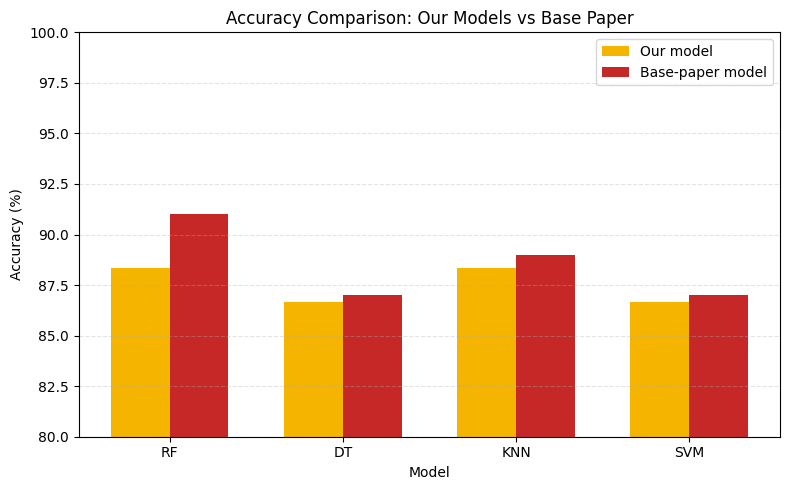

  Model  Our_Accuracy_%  Base_Paper_Accuracy_%
0    RF           88.33                   91.0
1    DT           86.67                   87.0
2   KNN           88.33                   89.0
3   SVM           86.67                   87.0


In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Our model accuracies from this notebook (converted to %)
our_accuracies = {
    "RF": rf_accuracy * 100,
    "DT": dt_accuracy * 100,
    "KNN": knn_accuracy * 100,
    "SVM": svm_accuracy * 100,
}

# Base-paper accuracies (approx. from the paper graph).
# Update these numbers if you have exact values from the paper table.
base_paper_accuracies = {
    "RF": 91.0,
    "DT": 87.0,
    "KNN": 89.0,
    "SVM": 87.0,
}

models = ["RF", "DT", "KNN", "SVM"]
our_vals = [our_accuracies[m] for m in models]
base_vals = [base_paper_accuracies[m] for m in models]

x = np.arange(len(models))
width = 0.34

plt.figure(figsize=(8, 5))
plt.bar(x - width / 2, our_vals, width, label="Our model", color="#F4B400")
plt.bar(x + width / 2, base_vals, width, label="Base-paper model", color="#C62828")

plt.xticks(x, models)
plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.ylim(80, 100)
plt.title("Accuracy Comparison: Our Models vs Base Paper")
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.legend()

plt.tight_layout()
plt.show()

comparison_df = pd.DataFrame({
    "Model": models,
    "Our_Accuracy_%": np.round(our_vals, 2),
    "Base_Paper_Accuracy_%": np.round(base_vals, 2),
})
print(comparison_df)

In [17]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix, accuracy_score

def calculate_model_metrics(y_true, y_pred, model, X_test):
    """
    Calculate comprehensive metrics for a model
    
    Parameters:
    - y_true: actual labels
    - y_pred: predicted labels
    - model: trained model object
    - X_test: test features for probability/score calculation
    
    Returns:
    - Dictionary with all metrics
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    
    # Get probability scores for AUC calculation
    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_scores = model.decision_function(X_test)
    else:
        y_scores = y_pred
    
    # Calculate AUC
    try:
        auc_score = roc_auc_score(y_true, y_scores)
    except:
        auc_score = 0.0
    
    return {
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Specificity": specificity,
        "F-measure": f1_score(y_true, y_pred, zero_division=0),
        "AUC": auc_score,
    }

# Calculate metrics for each model
print("="*70)
print("COMPREHENSIVE MODEL METRICS")
print("="*70)

results = {}

# SVM Metrics
results["SVM"] = calculate_model_metrics(y_test, y_pred_svm, svm_model, X_test_scaled)
print("\nSVM Metrics:")
for metric, value in results["SVM"].items():
    print(f"  {metric:15s}: {value:.4f}")

# KNN Metrics
results["KNN"] = calculate_model_metrics(y_test, y_pred_knn, knn_model, X_test_scaled)
print("\nKNN Metrics:")
for metric, value in results["KNN"].items():
    print(f"  {metric:15s}: {value:.4f}")

# Decision Tree Metrics
results["DT"] = calculate_model_metrics(y_test, y_pred_dt, dt_model, X_test_scaled)
print("\nDecision Tree Metrics:")
for metric, value in results["DT"].items():
    print(f"  {metric:15s}: {value:.4f}")

# Random Forest Metrics
results["RF"] = calculate_model_metrics(y_test, y_pred_rf, rf_model, X_test_scaled)
print("\nRandom Forest Metrics:")
for metric, value in results["RF"].items():
    print(f"  {metric:15s}: {value:.4f}")

# Create summary DataFrame
print("\n" + "="*70)
print("SUMMARY TABLE")
print("="*70)
results_df = pd.DataFrame(results).T
print(results_df.round(4))

COMPREHENSIVE MODEL METRICS

SVM Metrics:
  Precision      : 0.8846
  Sensitivity    : 0.8214
  MCC            : 0.7326
  Specificity    : 0.9062
  F-measure      : 0.8519
  AUC            : 0.9498

KNN Metrics:
  Precision      : 0.9565
  Sensitivity    : 0.7857
  MCC            : 0.7742
  Specificity    : 0.9688
  F-measure      : 0.8627
  AUC            : 0.9464

Decision Tree Metrics:
  Precision      : 0.9545
  Sensitivity    : 0.7500
  MCC            : 0.7441
  Specificity    : 0.9688
  F-measure      : 0.8400
  AUC            : 0.9141

Random Forest Metrics:
  Precision      : 0.9200
  Sensitivity    : 0.8214
  MCC            : 0.7680
  Specificity    : 0.9375
  F-measure      : 0.8679
  AUC            : 0.9358

SUMMARY TABLE
     Precision  Sensitivity     MCC  Specificity  F-measure     AUC
SVM     0.8846       0.8214  0.7326       0.9062     0.8519  0.9498
KNN     0.9565       0.7857  0.7742       0.9688     0.8627  0.9464
DT      0.9545       0.7500  0.7441       0.9688     